In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('../data/Task1/fishing_logs.csv')

In [ ]:
train

In [3]:
train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              2500 non-null   int64  
 1   Water Temperature (°C)  2500 non-null   float64
 2   Depth Pressure (kPa)    2500 non-null   float64
 3   Temp-Pressure Index     2500 non-null   float64
 4   Fish Activity Metric    2500 non-null   float64
 5   Catch Density Metric    2500 non-null   float64
 6   Catch Quality Rating    2500 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 136.8 KB


,Unnamed: 0,Water Temperature (°C),Depth Pressure (kPa),Temp-Pressure Index,Fish Activity Metric,Catch Density Metric,Catch Quality Rating
count,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1249.50000,20.065380,148.009369,29.665609,48.385167,1014.740481,0.096039
std,721.83216,5.861597,57.048455,14.614023,24.053926,767.829691,0.013306
min,0.00000,10.001474,50.098193,5.137069,10.156972,99.994622,0.001422
25%,624.75000,15.087518,98.211918,18.005287,27.504623,343.428536,0.099937
50%,1249.50000,20.029159,148.645970,27.082271,44.809455,803.482265,0.100000
75%,1874.25000,25.181181,197.224112,39.294715,68.156554,1596.699934,0.100000
max,2499.00000,29.996172,249.991323,73.650187,103.756181,2698.959648,0.100000


# Preprocess

In [4]:
train.drop(columns=['Unnamed: 0'], inplace=True)

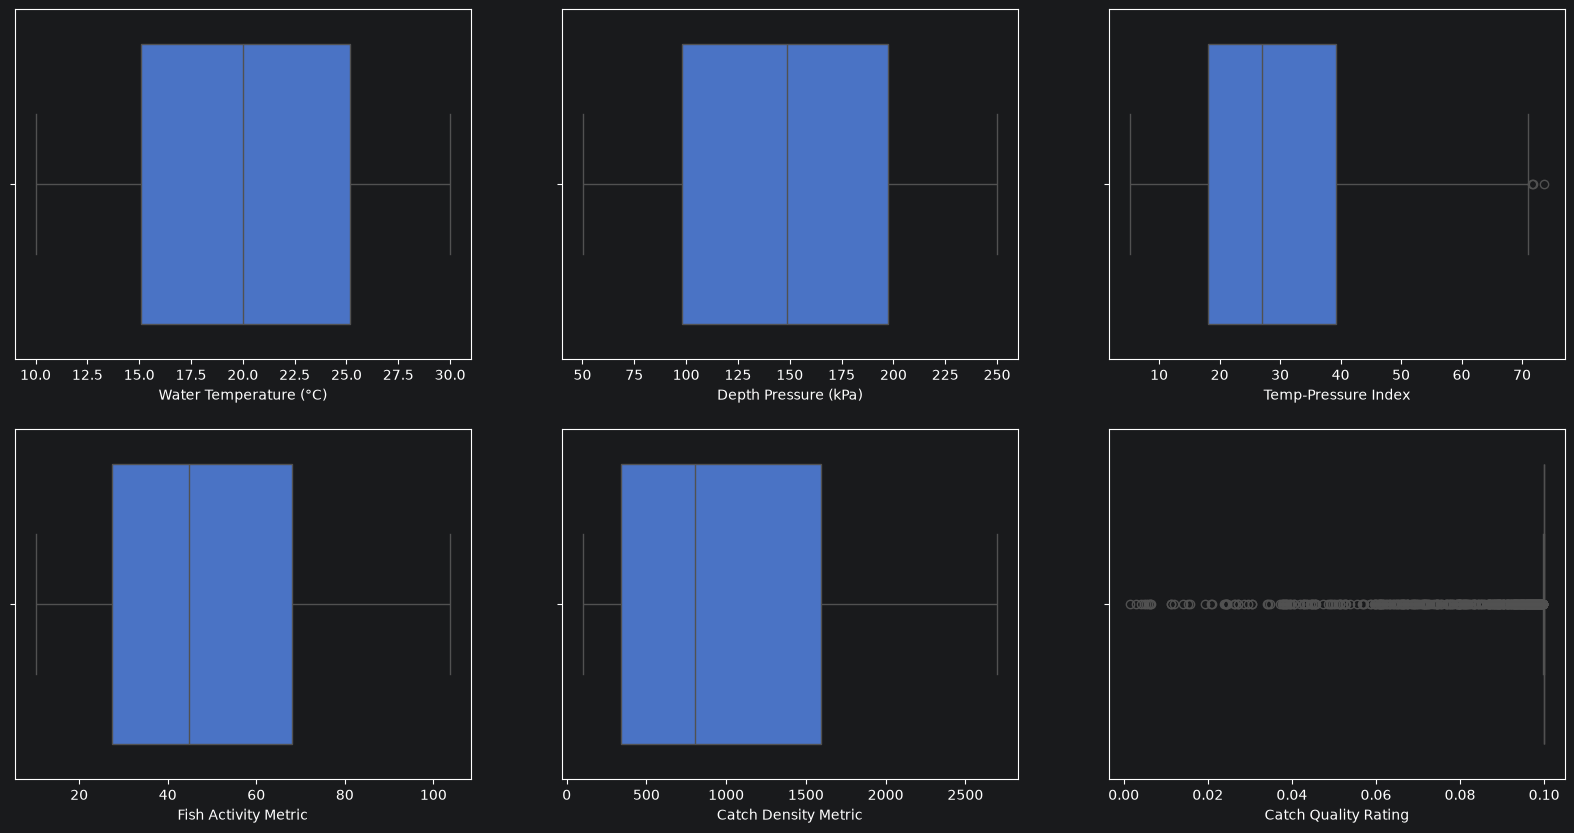

In [5]:
# boxplot to detect outliers
fig, ax = plt.subplots(2, 3, figsize=(20, 10))
sns.boxplot(x=train['Water Temperature (°C)'], ax=ax[0][0])
sns.boxplot(x=train['Depth Pressure (kPa)'], ax=ax[0][1])
sns.boxplot(x=train['Temp-Pressure Index'], ax=ax[0][2])
sns.boxplot(x=train['Fish Activity Metric'], ax=ax[1][0])
sns.boxplot(x=train['Catch Density Metric'], ax=ax[1][1])
sns.boxplot(x=train['Catch Quality Rating'], ax=ax[1][2])
plt.show()

In [6]:
# feature scaling
means = train.describe().T['mean']
stds = train.describe().T['std']
y_max, y_min = train.describe().at['max', 'Catch Quality Rating'], train.describe().at['min', 'Catch Quality Rating']
for col in train.columns:
    if not col == 'Catch Quality Rating':
        train[col] = (train[col] - means[col]) / stds[col]
train['Catch Quality Rating'] = (train['Catch Quality Rating'] - y_min) / (y_max - y_min)

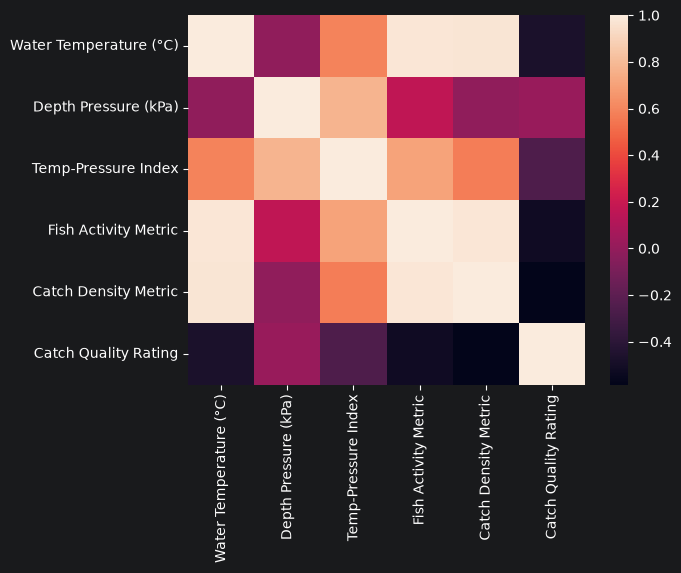

,Water Temperature (°C),Depth Pressure (kPa),Temp-Pressure Index,Fish Activity Metric,Catch Density Metric,Catch Quality Rating
Water Temperature (°C),1.000000,-0.009883,0.585975,0.975767,0.970969,-0.470129
Depth Pressure (kPa),-0.009883,1.000000,0.771878,0.160815,-0.009420,0.016942
Temp-Pressure Index,0.585975,0.771878,1.000000,0.703844,0.568807,-0.259878
Fish Activity Metric,0.975767,0.160815,0.703844,1.000000,0.977445,-0.519979
Catch Density Metric,0.970969,-0.009420,0.568807,0.977445,1.000000,-0.585221
Catch Quality Rating,-0.470129,0.016942,-0.259878,-0.519979,-0.585221,1.000000


In [7]:
# correlation to detect multicollinearity
sns.heatmap(train.corr())
plt.show()
display(train.corr())
# water T, T-P index, and catch density metric have high multicollinearity
# L2 regularization will take care of it

# Train

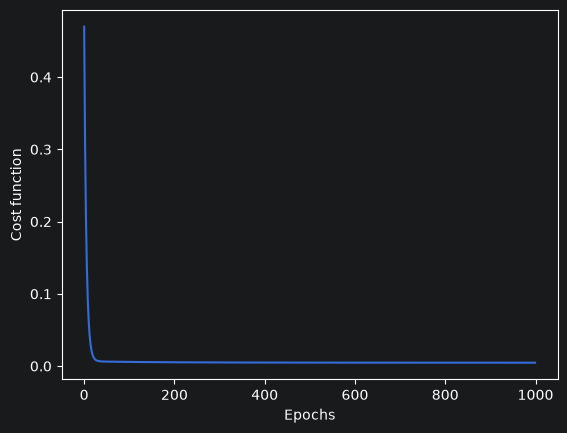

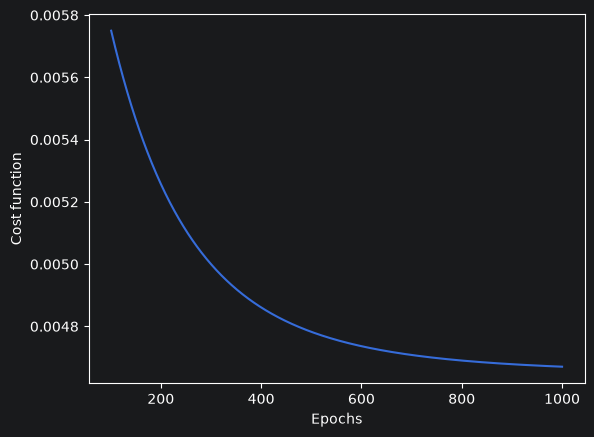

In [9]:
EPOCHS = 1000

x = np.hstack([np.ones((train.index.size, 1)), np.array(train.drop(columns=['Catch Quality Rating']))])
y = np.array(train[['Catch Quality Rating']])
weights = np.zeros((x.shape[1], 1))
alpha = 0.1
lam = 1
costs = np.zeros(EPOCHS)
for i in range(EPOCHS):
    hx = x @ weights
    weights -= alpha * (x.T @ (hx - y)) / x.shape[0]
    weights[1:] -= alpha * lam / x.shape[0] * weights[1:]
    costs[i] = np.mean((hx-y)**2) / 2 + lam * np.sum(weights**2) / x.shape[0] / 2

plt.xlabel('Epochs')
plt.ylabel('Cost function')
plt.plot(costs)
plt.show()
plt.xlabel('Epochs')
plt.ylabel('Cost function')
plt.plot(range(101, EPOCHS+1), costs[100:])
plt.show()

In [10]:
hx = x @ weights
mse = np.mean((hx-y)**2)
print('MSE for train dataset =', mse)

r2 = 1 - mse / np.var(y)
print('Coefficient of determination (measure of accuracy) =', r2)

MSE for train dataset = 0.008923782843537714
Coefficient of determination (measure of accuracy) = 0.5100211147100832


In [11]:
import random

# comparing random predicted and actual labels
idx = np.array([random.randrange(x.shape[0]) for _ in range(100)])
print('Predicted label\t\tActual label')
hx = (x[idx] @ weights)[:,0]
for i in range(100):
    print(f'{hx[i]*(y_max-y_min)+y_min}\t\t{y[idx[i],0]*(y_max-y_min)+y_min}')

Predicted label		Actual label
0.07454779137996395		0.07345964992
0.10446547958542882		0.09999999996
0.09042044970357016		0.09971549122
0.1032216234134727		0.1
0.10131607789355017		0.09999986156
0.10441514990077341		0.09999999991
0.10195565168059631		0.09999994201
0.0994913703062763		0.1
0.10088147951698767		0.1
0.1028989822041866		0.09999998667
0.1023177177736353		0.09999993411
0.09651362772077202		0.09998639225
0.09992966917893048		0.09999861351
0.08967567124218973		0.09966132214
0.08324057040141968		0.09754633177
0.10423585126476138		0.09999999906
0.09973533592097794		0.0999994818
0.10203716538865477		0.1
0.09562024817975227		0.1
0.08754309974003394		0.09917882941
0.09572895575778098		0.1
0.08856857926632271		0.09956574657
0.10306507574366768		0.1
0.08432673821733748		0.09857918104
0.07465219740332668		0.06062212801999999
0.08005742400354267		0.09108211858
0.09513471482544211		0.1
0.0968748079484183		0.09998971235
0.06999581616562237		0.03055833428
0.09618416627157474		0.09998939552


# Preprocess Inference Dataset

In [12]:
predict = pd.read_csv('../data/Task1/prediction_logs.csv')

In [ ]:
predict

In [14]:
predict.info()
predict.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1457 entries, 0 to 1456
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0.1            1457 non-null   int64  
 1   Unnamed: 0              1457 non-null   int64  
 2   Water Temperature (°C)  1457 non-null   float64
 3   Depth Pressure (kPa)    1457 non-null   float64
 4   Temp-Pressure Index     1457 non-null   float64
 5   Fish Activity Metric    1457 non-null   float64
 6   Catch Density Metric    1457 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 79.8 KB


,Unnamed: 0.1,Unnamed: 0,Water Temperature (°C),Depth Pressure (kPa),Temp-Pressure Index,Fish Activity Metric,Catch Density Metric
count,1457.000000,1457.000000,1457.000000,1457.000000,1457.000000,1457.000000,1457.000000
mean,728.000000,3228.000000,19.897242,148.406457,29.360358,47.684521,984.607733
std,420.743984,420.743984,5.730671,58.874410,14.530551,23.393220,746.073076
min,0.000000,2500.000000,10.001449,50.030076,5.344032,10.223877,99.998277
25%,364.000000,2864.000000,15.057598,95.104407,17.982473,27.782210,341.388853
50%,728.000000,3228.000000,19.544450,148.086131,26.543987,43.588706,746.549074
75%,1092.000000,3592.000000,25.044217,198.908537,39.149641,66.528108,1570.797050
max,1456.000000,3956.000000,29.999280,249.941676,72.842907,102.662613,2699.782613


In [15]:
predict.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], inplace=True)

In [16]:
for col in predict.columns:
    predict[col] = (predict[col] - means[col]) / stds[col]

# Inference

In [18]:
x = np.hstack([np.ones((predict.index.size, 1)), np.array(predict)])
predict['Catch Quality Rating'] = (x @ weights)[:,0]

In [19]:
# feature descaling
for col in predict.columns:
    if not col == 'Catch Quality Rating':
        predict[col] = predict[col] * stds[col] + means[col]
predict['Catch Quality Rating'] = predict['Catch Quality Rating'] * (y_max - y_min) + y_min

In [20]:
# write
predict.to_csv('../data/Task1/model_prediction.csv', index=False)